# Step 3. 포트폴리오 최적화 (계층형 배분)

30개 자산을 대상으로 **계층형 2단계 배분**을 수행합니다.

---

## 전체 구조

| 단계 | 내용 | 방법 |
|------|------|------|
| **Level 1** | 자산군 배분 (Equity / Bond / Alt) | 블록 대각 공분산 + Mean-Variance |
| **Level 2** | 그룹 내 종목 배분 | Equity: PCA Factor Cov, Bond/Alt: Ledoit-Wolf |

### 왜 계층형 배분인가?

- **직접 30×30 최적화의 문제**: 추정 오차가 크고, 극단적 집중 포트폴리오 발생 가능
- **Level 1**: 대표 ETF 3개(SPY, AGG, GLD)로 자산군 비중을 먼저 결정 → 안정적
- **Level 2**: 각 그룹 내에서 세부 종목 배분 → 그룹 내 상관이 높아 추정이 정밀
- **투자자 프로파일**: 위험회피계수(γ)에 따라 4가지 프로파일 자동 생성

### 3가지 최적화 전략

| 전략 | 설명 | 특성 |
|------|------|------|
| **Mean-Variance (MV)** | 효용함수 극대화 (U = μ - γ/2 · σ²) | 기대수익 활용, 추정 오차에 민감 |
| **Risk Parity (RP)** | 동일 위험 기여도 | 기대수익 불요, 분산 효과 극대화 |
| **HRP** | 계층적 위험 동등 배분 | 역공분산 불요, 클러스터 기반 안정적 |

In [1]:
# ============================================================
# 라이브러리 임포트 + 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ── 시각화 설정 ──
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ── 경로 설정 ──
V3_DIR   = os.getcwd()  # PJ12_v3_Final/
DATA_DIR = os.path.join(V3_DIR, 'data')
IMG_DIR  = os.path.join(V3_DIR, 'images')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ── 데이터 로드 ──
# Step1에서 저장한 30개 자산 일별 종가
df_prices = pd.read_csv(os.path.join(DATA_DIR, 'portfolio_prices.csv'),
                         index_col='Date', parse_dates=True)
print(f'가격 데이터: {df_prices.shape}')
print(f'기간: {df_prices.index[0].date()} ~ {df_prices.index[-1].date()}')

# ── 로그 수익률 계산 ──
# 로그 수익률: 시간 가산성 보장, 정규분포에 가까움
log_returns = np.log(df_prices / df_prices.shift(1)).dropna()
print(f'로그 수익률: {log_returns.shape}')

# ── 자산 그룹 정의 ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX',
              'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

# Equity 그룹 = 인덱스 ETF + 섹터 ETF + 개별 종목 (24개)
EQUITY_ALL = INDEX_ETF + SECTOR_ETF + STOCKS

print(f'\n자산 그룹:')
print(f'  EQUITY: {len(EQUITY_ALL)}개 (인덱스 {len(INDEX_ETF)} + 섹터 {len(SECTOR_ETF)} + 종목 {len(STOCKS)})')
print(f'  BOND:   {len(BOND_ETF)}개')
print(f'  ALT:    {len(ALT_ETF)}개')
print(f'  합계:   {len(EQUITY_ALL) + len(BOND_ETF) + len(ALT_ETF)}개')

가격 데이터: (2609, 30)
기간: 2016-01-01 ~ 2025-12-31
로그 수익률: (2608, 30)

자산 그룹:
  EQUITY: 24개 (인덱스 5 + 섹터 11 + 종목 8)
  BOND:   4개
  ALT:    2개
  합계:   30개


---

## 3-1. 투자자 성향 프로파일 (generate_profile)

위험회피계수 **γ (gamma)**를 기반으로 투자자 프로파일을 연속 함수로 생성합니다.

### 설계 원리

- **γ = 1** (공격형): 높은 변동성 허용, 주식 비중 최대
- **γ = 8** (보수형): 낮은 변동성, 채권 비중 최소 40%
- 중간값은 선형 보간: `t = (γ - 1) / 9` → 0~1 사이 정규화

### MDD 기반 종목별 비중 상한

각 프로파일의 **최대허용 MDD**를 기반으로 개별 종목의 비중 상한을 역산합니다.
- 극단 충격(extreme_shock) = 50% 하락 가정
- MDD 분배: 전체 MDD의 1/3을 단일 종목에 허용
- 종목 유형별 승수: 인덱스 ETF > 섹터 ETF > 개별 종목
- HHI 상한: 과도한 집중 방지 (γ에 따라 15%~25%)

In [2]:
# ============================================================
# 투자자 프로파일 생성 함수
# ============================================================

def generate_profile(gamma):
    """
    위험회피계수(gamma)로 투자자 프로파일 자동 생성.
    
    t = (gamma - 1) / 9 → [0, 1] 정규화
    - t=0 (gamma=1, 공격형): 높은 변동성 허용, 주식 비중 최대
    - t=1 (gamma=10): 최저 변동성, 채권 중심
    """
    t = (gamma - 1) / 9
    return {
        'gamma': gamma,
        'target_vol': 0.22 - 0.15 * t,       # 22% → 7%
        'max_equity': 0.90 - 0.60 * t,        # 90% → 30%
        'min_bond': 0.00 + 0.40 * t,          # 0% → 40%
        'max_mdd': -(0.35 - 0.25 * t),        # -35% → -10%
    }


def get_weight_bounds(gamma, asset_type):
    """
    MDD 기반 종목별 비중 상한 계산.
    
    로직:
    1. 프로파일의 max_mdd에서 극단 충격(50% 하락) 시 단일 종목 기여분 역산
    2. 종목 유형별 승수 적용 (인덱스 ETF는 분산 효과가 크므로 상한 완화)
    3. HHI 상한으로 과도한 집중 방지
    
    Parameters:
        gamma: 위험회피계수
        asset_type: 'index_etf', 'sector_etf', 'individual'
    Returns:
        (lower_bound, upper_bound) 튜플
    """
    profile = generate_profile(gamma)
    max_mdd = abs(profile['max_mdd'])
    
    # 극단 충격 시나리오: 개별 종목이 50% 하락한다고 가정
    extreme_shock = 0.50
    # MDD의 1/3을 단일 종목에 배분 → 단일 종목 비중 상한
    mdd_fraction = 1 / 3
    raw_max = (max_mdd * mdd_fraction) / extreme_shock
    
    # 종목 유형별 승수: 인덱스 ETF는 이미 분산되어 있으므로 상한 완화
    multipliers = {
        'index_etf': 1.4,      # 분산 ETF → 상한 40% 완화
        'sector_etf': 1.1,     # 섹터 ETF → 상한 10% 완화
        'individual': 1.0      # 개별 종목 → 기본
    }
    
    # HHI(허핀달-허쉬만) 기반 집중도 상한: gamma가 높을수록 분산 강제
    hhi_caps = {
        8: 0.15, 7: 0.15, 6: 0.15, 5: 0.15, 4: 0.15,
        3: 0.20, 2: 0.20, 1: 0.25
    }
    hhi_cap = hhi_caps.get(int(round(gamma)), 0.20)
    
    m = multipliers[asset_type]
    return (0.0, min(raw_max * m, hhi_cap))


# ── 4가지 사전 정의 프로파일 ──
PRESETS = {
    '보수형': generate_profile(8),
    '중립형': generate_profile(4),
    '적극형': generate_profile(2),
    '공격형': generate_profile(1),
}

# 프로파일 테이블 출력
print('=' * 70)
print('투자자 프로파일 요약')
print('=' * 70)
print(f'{"프로파일":>8s} | {"γ":>4s} | {"목표변동성":>10s} | {"최대주식":>8s} | {"최소채권":>8s} | {"최대MDD":>8s}')
print('-' * 70)
for name, p in PRESETS.items():
    print(f'{name:>8s} | {p["gamma"]:4.0f} | {p["target_vol"]:>9.1%} | {p["max_equity"]:>7.0%} | {p["min_bond"]:>7.0%} | {p["max_mdd"]:>7.1%}')

# 비중 상한 예시 출력
print(f'\n종목별 비중 상한 예시 (γ=4, 중립형):')
for at in ['index_etf', 'sector_etf', 'individual']:
    lb, ub = get_weight_bounds(4, at)
    print(f'  {at:12s}: [{lb:.1%}, {ub:.1%}]')

투자자 프로파일 요약
    프로파일 |    γ |      목표변동성 |     최대주식 |     최소채권 |    최대MDD
----------------------------------------------------------------------
     보수형 |    8 |     10.3% |     43% |     31% |  -15.6%
     중립형 |    4 |     17.0% |     70% |     13% |  -26.7%
     적극형 |    2 |     20.3% |     83% |      4% |  -32.2%
     공격형 |    1 |     22.0% |     90% |      0% |  -35.0%

종목별 비중 상한 예시 (γ=4, 중립형):
  index_etf   : [0.0%, 15.0%]
  sector_etf  : [0.0%, 15.0%]
  individual  : [0.0%, 15.0%]


In [ ]:
# ============================================================
# 시각화: 투자자 프로파일 비교 (2-subplot 분리)
# ============================================================
# 4개 파라미터가 의미적으로 다른 두 그룹이므로 subplot 분리:
#   왼쪽  - 자산 배분 제약 (최대 주식 상한 / 최소 채권 하한)
#   오른쪽 - 리스크 지표   (목표 변동성 σ / 최대 MDD 한계)
# 단일 축에 함께 그리면 "합산 100% 초과" 오해가 생기므로 분리.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

profile_names = list(PRESETS.keys())
x = np.arange(len(profile_names))
width = 0.35

# ---- 왼쪽: 자산 배분 제약 ----
alloc_labels = ['최대 주식 비중 (상한)', '최소 채권 비중 (하한)']
alloc_colors = ['#1f77b4', '#ff7f0e']
alloc_data = np.array([
    [PRESETS[n]['max_equity'] for n in profile_names],
    [PRESETS[n]['min_bond']   for n in profile_names],
])

for i, (lbl, c) in enumerate(zip(alloc_labels, alloc_colors)):
    bars = ax1.bar(x + (i - 0.5) * width, alloc_data[i] * 100,
                   width=width, label=lbl, color=c, alpha=0.85,
                   edgecolor='black', linewidth=0.3)
    for bar, val in zip(bars, alloc_data[i]):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels([f'{n}\n(γ={PRESETS[n]["gamma"]})' for n in profile_names],
                    fontsize=10)
ax1.set_ylabel('포트폴리오 비중 (%)', fontsize=11)
ax1.set_title('자산 배분 제약 (비중 상/하한)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ---- 오른쪽: 리스크 지표 ----
risk_labels = ['목표 변동성 (연환산 σ)', '|최대 MDD| (허용 한계)']
risk_colors = ['#2ca02c', '#d62728']
risk_data = np.array([
    [PRESETS[n]['target_vol']       for n in profile_names],
    [abs(PRESETS[n]['max_mdd'])     for n in profile_names],
])

for i, (lbl, c) in enumerate(zip(risk_labels, risk_colors)):
    bars = ax2.bar(x + (i - 0.5) * width, risk_data[i] * 100,
                   width=width, label=lbl, color=c, alpha=0.85,
                   edgecolor='black', linewidth=0.3)
    for bar, val in zip(bars, risk_data[i]):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels([f'{n}\n(γ={PRESETS[n]["gamma"]})' for n in profile_names],
                    fontsize=10)
ax2.set_ylabel('연환산 리스크 지표 (%)', fontsize=11)
ax2.set_title('리스크 지표 (통계적 속성)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.set_ylim(0, 50)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('투자자 프로파일 비교: 핵심 파라미터',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step3_01_profiles.png'),
            bbox_inches='tight', dpi=120)
plt.show()
print('저장: images/step3_01_profiles.png')


---

## 3-2. Level 1: 자산군 배분 (블록 대각)

### 블록 대각 공분산이란?

30개 자산을 직접 최적화하는 대신, **3개 대표 ETF**로 자산군 수준의 배분을 먼저 결정합니다.

| 대표 ETF | 자산군 | 역할 |
|----------|--------|------|
| **SPY** | Equity (주식) | S&P 500, 전체 주식군 대표 |
| **AGG** | Bond (채권) | 미국 종합채권, 전체 채권군 대표 |
| **GLD** | Alternative (대안) | 금 ETF, 대안자산군 대표 |

### 왜 블록 대각인가?

- 3×3 공분산만 추정하면 되므로 **추정 오차가 극히 적음**
- Ledoit-Wolf 수축 추정으로 안정성 추가 확보
- 투자자 프로파일의 제약조건(최대 주식, 최소 채권)을 직접 적용 가능

In [4]:
# ============================================================
# Level 1: 자산군 배분 (블록 대각 공분산)
# ============================================================

# Level 1 대표 ETF: 각 자산군의 대표 지수
L1_REPS = ['SPY', 'AGG', 'GLD']
L1_LABELS = ['Equity', 'Bond', 'Alt']

# 대표 ETF 로그 수익률
l1_ret = log_returns[L1_REPS]

# 연율화 기대수익률 (과거 평균 기반)
l1_mu = l1_ret.mean().values * 252

# Ledoit-Wolf 수축 공분산 (연율화)
# 표본 공분산보다 조건수가 개선되어 최적화 안정성 향상
l1_cov = LedoitWolf().fit(l1_ret).covariance_ * 252

print('=== Level 1 입력 데이터 ===')
print(f'\n연율화 기대수익률:')
for label, ticker, mu in zip(L1_LABELS, L1_REPS, l1_mu):
    print(f'  {label:8s} ({ticker}): {mu:+.2%}')

print(f'\nLedoit-Wolf 수축 공분산 (연율화):')
cov_df = pd.DataFrame(l1_cov, index=L1_REPS, columns=L1_REPS)
print(cov_df.round(6).to_string())

# 상관행렬도 확인
std = np.sqrt(np.diag(l1_cov))
corr = l1_cov / np.outer(std, std)
print(f'\n상관행렬:')
print(pd.DataFrame(corr, index=L1_REPS, columns=L1_REPS).round(3).to_string())

=== Level 1 입력 데이터 ===

연율화 기대수익률:
  Equity   (SPY): +13.47%
  Bond     (AGG): +1.92%
  Alt      (GLD): +13.09%

Ledoit-Wolf 수축 공분산 (연율화):
          SPY       AGG       GLD
SPY  0.031060  0.001060  0.001283
AGG  0.001060  0.003162  0.002564
GLD  0.001283  0.002564  0.021062

상관행렬:
       SPY    AGG    GLD
SPY  1.000  0.107  0.050
AGG  0.107  1.000  0.314
GLD  0.050  0.314  1.000


In [5]:
# ============================================================
# Level 1 최적화 함수 + 4개 프로파일 배분
# ============================================================

def level1_allocate(profile, mu, cov):
    """
    Level 1 자산군 배분: Mean-Variance 효용 극대화.
    
    U = w'μ - (γ/2) · w'Σw  를 최대화하되,
    프로파일의 제약조건(최대주식, 최소채권)을 반영합니다.
    
    Parameters:
        profile: generate_profile() 결과 딕셔너리
        mu: 3×1 기대수익률 벡터 (연율화)
        cov: 3×3 공분산 행렬 (연율화)
    Returns:
        w: 3×1 비중 벡터 [equity, bond, alt]
    """
    gamma = profile['gamma']
    
    # 목적함수: 효용 극대화 (부호 반전 → 최소화)
    def neg_utility(w):
        return -(w @ mu - (gamma / 2) * w @ cov @ w)
    
    # 제약조건: 비중 합 = 1
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    
    # 프로파일 제약: 최대 주식 비중, 최소 채권 비중
    max_eq = profile['max_equity']
    min_bond = profile['min_bond']
    
    # 주식 비중 ≤ max_equity
    constraints.append({'type': 'ineq', 'fun': lambda w: max_eq - w[0]})
    # 채권 비중 ≥ min_bond (min_bond > 0인 경우에만)
    if min_bond > 0:
        constraints.append({'type': 'ineq', 'fun': lambda w: w[1] - min_bond})
    
    # 비중 범위: 모두 0~1, 주식은 max_equity로 제한
    bounds = [(0, max_eq), (0, 1), (0, 1)]
    
    # 초기값: 균등 배분에서 시작
    w0 = np.array([0.4, 0.4, 0.2])
    
    try:
        result = minimize(neg_utility, w0, method='SLSQP',
                         bounds=bounds, constraints=constraints,
                         options={'maxiter': 1000, 'ftol': 1e-12})
        if result.success:
            w = np.maximum(result.x, 0)  # 음수 방지
            return w / w.sum()            # 정규화
        else:
            print(f'  [WARN] 최적화 수렴 실패 (γ={gamma}): {result.message}')
            # 폴백: 프로파일 제약에 맞는 보수적 배분
            w = np.array([max_eq * 0.5, max(min_bond, 0.3), 0.1])
            return w / w.sum()
    except Exception as e:
        print(f'  [ERR] 최적화 실패 (γ={gamma}): {e}')
        w = np.array([0.4, 0.4, 0.2])
        return w / w.sum()


# ── 4개 프로파일별 Level 1 배분 ──
l1_weights = {}
print('=' * 60)
print('Level 1 자산군 배분 결과')
print('=' * 60)
print(f'{"프로파일":>8s} | {"Equity":>8s} | {"Bond":>8s} | {"Alt":>8s} | {"포트 수익률":>10s} | {"포트 변동성":>10s}')
print('-' * 60)

for name, profile in PRESETS.items():
    w = level1_allocate(profile, l1_mu, l1_cov)
    l1_weights[name] = w
    
    # 포트폴리오 기대수익률과 변동성 계산
    port_ret = w @ l1_mu
    port_vol = np.sqrt(w @ l1_cov @ w)
    
    print(f'{name:>8s} | {w[0]:>7.1%} | {w[1]:>7.1%} | {w[2]:>7.1%} | {port_ret:>+9.2%} | {port_vol:>9.2%}')

Level 1 자산군 배분 결과
    프로파일 |   Equity |     Bond |      Alt |     포트 수익률 |     포트 변동성
------------------------------------------------------------
     보수형 |   29.4% |   31.1% |   39.5% |    +9.73% |     8.60%
     중립형 |   36.9% |   13.3% |   49.8% |   +11.74% |    10.21%
     적극형 |   42.1% |    4.4% |   53.4% |   +12.76% |    11.08%
     공격형 |   47.6% |    0.0% |   52.4% |   +13.27% |    11.60%


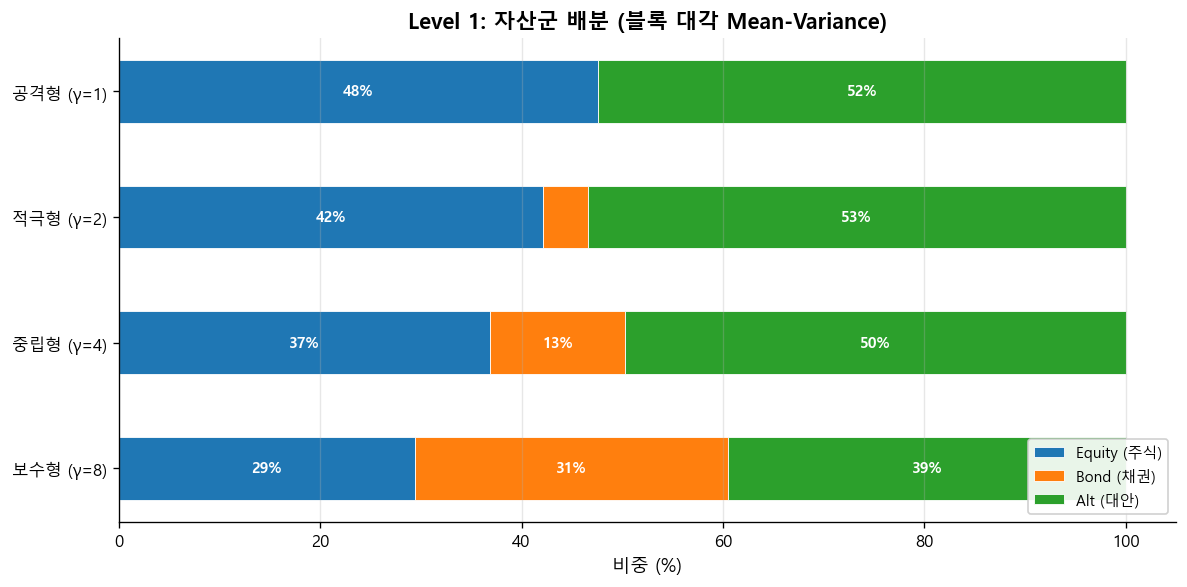

저장: images/step3_02_level1_allocation.png


In [6]:
# ============================================================
# 시각화: Level 1 자산군 배분 (적층형 막대 차트)
# ============================================================
# 4개 프로파일의 자산군 배분을 적층형 가로 막대로 비교

fig, ax = plt.subplots(figsize=(10, 5))

profile_names = list(l1_weights.keys())
equity_w = [l1_weights[n][0] * 100 for n in profile_names]
bond_w = [l1_weights[n][1] * 100 for n in profile_names]
alt_w = [l1_weights[n][2] * 100 for n in profile_names]

y_pos = np.arange(len(profile_names))

# 적층형 가로 막대
bars1 = ax.barh(y_pos, equity_w, height=0.5, label='Equity (주식)',
                color='#1f77b4', edgecolor='white', linewidth=0.5)
bars2 = ax.barh(y_pos, bond_w, height=0.5, left=equity_w, label='Bond (채권)',
                color='#ff7f0e', edgecolor='white', linewidth=0.5)
bars3 = ax.barh(y_pos, alt_w, height=0.5,
                left=[e + b for e, b in zip(equity_w, bond_w)],
                label='Alt (대안)', color='#2ca02c', edgecolor='white', linewidth=0.5)

# 값 라벨
for i, name in enumerate(profile_names):
    w = l1_weights[name]
    # 각 자산군 비중 텍스트
    if w[0] > 0.05:
        ax.text(w[0] * 100 / 2, i, f'{w[0]:.0%}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    if w[1] > 0.05:
        ax.text(w[0] * 100 + w[1] * 100 / 2, i, f'{w[1]:.0%}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    if w[2] > 0.05:
        ax.text((w[0] + w[1]) * 100 + w[2] * 100 / 2, i, f'{w[2]:.0%}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{name} (γ={PRESETS[name]["gamma"]})' for name in profile_names],
                    fontsize=10)
ax.set_xlabel('비중 (%)', fontsize=11)
ax.set_title('Level 1: 자산군 배분 (블록 대각 Mean-Variance)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step3_02_level1_allocation.png'), bbox_inches='tight')
plt.show()
print('저장: images/step3_02_level1_allocation.png')

---

## 3-3. Level 2: 그룹 내 배분

Level 1에서 결정된 자산군 비중을 유지하면서, 각 그룹 내에서 종목별 비중을 결정합니다.

### 공분산 추정 방법

| 그룹 | 종목 수 | 공분산 추정 | 이유 |
|------|---------|-------------|------|
| **Equity** | 24개 | **PCA Factor Covariance** | 종목 수 대비 관측치 적음, 팩터 구조 활용 |
| **Bond** | 4개 | **Ledoit-Wolf** | 종목 수가 적어 수축 추정만으로 충분 |
| **Alt** | 2개 | **단순 역변동성** | 2개 자산이므로 역변동성 비율로 배분 |

### PCA Factor Covariance란?

24×24 표본 공분산을 직접 추정하면 노이즈가 큽니다.  
PCA로 주요 팩터를 추출하고, 팩터 공분산 + 잔차 분산으로 재구성하면:

$$\Sigma_{\text{factor}} = B \cdot \Sigma_F \cdot B^T + \text{diag}(\sigma^2_{\epsilon})$$

- $B$: N×K 팩터 로딩 행렬
- $\Sigma_F$: K×K 팩터 공분산
- $\sigma^2_{\epsilon}$: 잔차(고유) 분산

이 방식은 노이즈를 필터링하면서도 자산 간 공분산 구조를 보존합니다.

In [7]:
# ============================================================
# PCA Factor Covariance 함수
# ============================================================

def select_n_factors(returns, min_var=0.80, max_k=10):
    """
    누적 설명분산이 min_var를 넘는 최소 팩터 수 결정.
    최소 3개, 최대 max_k개.
    
    Parameters:
        returns: DataFrame, 일별 수익률
        min_var: 최소 누적 설명분산 비율 (기본 80%)
        max_k: 최대 팩터 수
    Returns:
        k: 선택된 팩터 수
    """
    pca = PCA(n_components=min(max_k, returns.shape[1]))
    pca.fit(returns)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    # 80% 이상 설명하는 최소 팩터 수 (최소 3개)
    k = max(3, int(np.argmax(cumvar >= min_var) + 1))
    return min(k, max_k)


def factor_covariance(returns, n_factors=None):
    """
    PCA 기반 팩터 공분산 행렬 추정.
    
    과정:
    1. PCA로 K개 주요 팩터 추출
    2. 팩터 로딩 × 팩터 공분산 × 팩터 로딩^T 로 공통 분산 계산
    3. 잔차 분산을 대각행렬로 추가
    4. 연율화 (×252)
    
    Parameters:
        returns: DataFrame, 일별 수익률
        n_factors: 팩터 수 (None이면 자동 선택)
    Returns:
        cov: N×N 팩터 공분산 행렬 (연율화)
        n_factors: 사용된 팩터 수
    """
    if n_factors is None:
        n_factors = select_n_factors(returns)
    
    pca = PCA(n_components=n_factors)
    factors = pca.fit_transform(returns)  # T×K 팩터 점수
    loadings = pca.components_.T           # N×K 팩터 로딩
    
    # 팩터 공분산 (K×K)
    factor_cov = np.cov(factors, rowvar=False)
    
    # 잔차: 원본 - 팩터로 설명되는 부분
    explained = factors @ loadings.T
    residuals = returns.values - explained
    residual_var = np.var(residuals, axis=0)  # 고유 분산
    
    # 팩터 공분산 = 공통분산 + 고유분산
    # Σ = B·Σ_F·B^T + diag(σ²_ε)
    cov = loadings @ factor_cov @ loadings.T + np.diag(residual_var)
    
    return cov * 252, n_factors  # 연율화


# ── Equity 그룹 PCA Factor Covariance 테스트 ──
eq_ret = log_returns[EQUITY_ALL]
eq_cov, n_factors = factor_covariance(eq_ret)

print(f'Equity 그룹 PCA Factor Covariance:')
print(f'  종목 수: {len(EQUITY_ALL)}개')
print(f'  선택된 팩터 수: {n_factors}개')
print(f'  공분산 행렬 크기: {eq_cov.shape}')
print(f'  조건수: {np.linalg.cond(eq_cov):.0f}')

# 비교: 표본 공분산의 조건수
sample_cov = eq_ret.cov().values * 252
print(f'  (참고) 표본 공분산 조건수: {np.linalg.cond(sample_cov):.0f}')
print(f'  → PCA 팩터 공분산이 조건수를 {np.linalg.cond(sample_cov)/np.linalg.cond(eq_cov):.1f}배 개선')

Equity 그룹 PCA Factor Covariance:
  종목 수: 24개
  선택된 팩터 수: 4개
  공분산 행렬 크기: (24, 24)
  조건수: 825
  (참고) 표본 공분산 조건수: 3985
  → PCA 팩터 공분산이 조건수를 4.8배 개선


In [8]:
# ============================================================
# 3가지 최적화 전략 함수
# ============================================================

def _get_asset_type(ticker):
    """티커의 자산 유형 반환 (비중 상한 계산용)"""
    if ticker in INDEX_ETF:
        return 'index_etf'
    elif ticker in SECTOR_ETF:
        return 'sector_etf'
    else:
        return 'individual'


def optimize_mv(profile, mu, cov, tickers):
    """
    Mean-Variance 최적화: 효용함수 극대화.
    
    U = w'μ - (γ/2) · w'Σw
    
    Parameters:
        profile: 투자자 프로파일
        mu: N×1 기대수익률 벡터 (연율화)
        cov: N×N 공분산 행렬 (연율화)
        tickers: 종목 리스트
    Returns:
        w: N×1 비중 벡터
    """
    gamma = profile['gamma']
    n = len(tickers)
    asset_types = [_get_asset_type(t) for t in tickers]
    
    # 목적함수: 효용 극대화 (부호 반전)
    def neg_utility(w):
        return -(w @ mu - (gamma / 2) * w @ cov @ w)
    
    # 제약: 비중 합 = 1
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    
    # 종목별 비중 상한 (MDD 기반)
    bounds = [get_weight_bounds(gamma, asset_types[i]) for i in range(n)]
    
    w0 = np.ones(n) / n  # 균등 배분 초기값
    
    try:
        result = minimize(neg_utility, w0, method='SLSQP',
                         bounds=bounds, constraints=constraints,
                         options={'maxiter': 2000, 'ftol': 1e-12})
        if result.success:
            w = np.maximum(result.x, 0)
            return w / w.sum()
        else:
            print(f'  [WARN] MV 수렴 실패: {result.message}')
            return np.ones(n) / n  # 폴백: 균등 배분
    except Exception as e:
        print(f'  [ERR] MV 최적화 실패: {e}')
        return np.ones(n) / n


def optimize_rp(cov, tickers, gamma):
    """
    Risk Parity 최적화: 동일 위험 기여도.
    
    각 종목의 위험 기여도(RC)가 동일하도록 비중 결정.
    기대수익률 추정이 불요하여 추정 오차에 강건함.
    
    Parameters:
        cov: N×N 공분산 행렬
        tickers: 종목 리스트
        gamma: 위험회피계수 (비중 상한 계산용)
    Returns:
        w: N×1 비중 벡터
    """
    n = len(tickers)
    asset_types = [_get_asset_type(t) for t in tickers]
    
    def risk_budget_obj(w):
        """위험 기여도 균등화 목적함수"""
        port_vol = np.sqrt(w @ cov @ w)
        # 한계 위험 기여도 (MRC)
        mrc = cov @ w / port_vol
        # 위험 기여도 (RC) = 비중 × MRC
        rc = w * mrc
        # 목표: 각 RC가 port_vol/n 과 같아야 함
        target_rc = port_vol / n
        return np.sum((rc - target_rc) ** 2)
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    
    # 비중 상한 적용 (하한은 0.001로 설정 → 0 비중 방지)
    bounds = [get_weight_bounds(gamma, asset_types[i]) for i in range(n)]
    bounds = [(max(b[0], 0.001), b[1]) for b in bounds]
    
    w0 = np.ones(n) / n
    
    try:
        result = minimize(risk_budget_obj, w0, method='SLSQP',
                         bounds=bounds, constraints=constraints,
                         options={'maxiter': 2000, 'ftol': 1e-15})
        if result.success:
            w = np.maximum(result.x, 0)
            return w / w.sum()
        else:
            print(f'  [WARN] RP 수렴 실패: {result.message}')
            return np.ones(n) / n
    except Exception as e:
        print(f'  [ERR] RP 최적화 실패: {e}')
        return np.ones(n) / n


def optimize_hrp(returns):
    """
    HRP (Hierarchical Risk Parity): 계층적 위험 동등 배분.
    
    Marcos Lopez de Prado (2016) 알고리즘:
    1. 상관 거리 기반 계층적 클러스터링
    2. 클러스터 순서에 따라 자산 재배열
    3. 이분할 재귀적 역분산 배분
    
    장점: 역공분산 행렬이 불요, 비볼록 최적화 없음
    
    Parameters:
        returns: DataFrame, 일별 수익률
    Returns:
        weights: Series, 종목별 비중
    """
    cov = returns.cov() * 252
    corr = returns.corr()
    
    # 상관 거리: d = sqrt((1 - ρ) / 2)
    dist = np.sqrt((1 - corr) / 2)
    np.fill_diagonal(dist.values, 0)
    
    # Ward 계층적 클러스터링
    link = linkage(squareform(dist.values), method='ward')
    sort_idx = leaves_list(link)
    sorted_tickers = [returns.columns[i] for i in sort_idx]
    
    # 초기 비중: 모두 1.0
    weights = pd.Series(1.0, index=sorted_tickers)
    
    def bisect(items):
        """이분할 재귀적 역분산 배분"""
        if len(items) <= 1:
            return
        mid = len(items) // 2
        left, right = items[:mid], items[mid:]
        
        # 각 하위 그룹의 분산 합 계산
        var_left = cov.loc[left, left].values
        var_right = cov.loc[right, right].values
        
        # 역분산 비율로 배분
        inv_l = 1 / np.diag(var_left).sum()
        inv_r = 1 / np.diag(var_right).sum()
        alloc = inv_l / (inv_l + inv_r)  # 왼쪽 배분 비율
        
        weights[left] *= alloc
        weights[right] *= (1 - alloc)
        
        bisect(left)
        bisect(right)
    
    bisect(sorted_tickers)
    
    # 원래 종목 순서로 재정렬
    return (weights / weights.sum()).reindex(returns.columns)


print('최적화 함수 3개 정의 완료:')
print('  1. optimize_mv()  — Mean-Variance (효용 극대화)')
print('  2. optimize_rp()  — Risk Parity (동일 위험 기여)')
print('  3. optimize_hrp() — HRP (계층적 역분산 배분)')

최적화 함수 3개 정의 완료:
  1. optimize_mv()  — Mean-Variance (효용 극대화)
  2. optimize_rp()  — Risk Parity (동일 위험 기여)
  3. optimize_hrp() — HRP (계층적 역분산 배분)


In [9]:
# ============================================================
# Level 2 최적화 실행: 4 프로파일 × 3 전략
# ============================================================
# Equity: PCA Factor Covariance + MV/RP/HRP
# Bond: Ledoit-Wolf + MV only
# Alt: 2개 자산 → 역변동성 비율

# ── Equity 그룹 준비 ──
eq_ret = log_returns[EQUITY_ALL]
eq_mu = eq_ret.mean().values * 252  # 연율화 기대수익률
eq_cov, n_factors_eq = factor_covariance(eq_ret)  # PCA Factor Covariance
print(f'Equity 그룹: {len(EQUITY_ALL)}개 종목, PCA {n_factors_eq}개 팩터')

# ── Bond 그룹 준비 ──
bond_ret = log_returns[BOND_ETF]
bond_mu = bond_ret.mean().values * 252
bond_cov = LedoitWolf().fit(bond_ret).covariance_ * 252  # Ledoit-Wolf
print(f'Bond 그룹: {len(BOND_ETF)}개 종목, Ledoit-Wolf 공분산')

# ── Alt 그룹 준비 ──
# 2개 자산이므로 역변동성 비율로 단순 배분
alt_ret = log_returns[ALT_ETF]
alt_vol = alt_ret.std().values * np.sqrt(252)  # 연율화 변동성
alt_inv_vol = 1 / alt_vol
alt_w_base = alt_inv_vol / alt_inv_vol.sum()  # 역변동성 비중
print(f'Alt 그룹: {ALT_ETF}, 역변동성 비중 = {dict(zip(ALT_ETF, alt_w_base.round(3)))}')

# ── 전체 결과 저장용 딕셔너리 ──
# 구조: all_weights[프로파일명][전략명] = pd.Series (30개 자산 비중)
all_weights = {}

print('\n' + '=' * 80)
print('Level 2 최적화 실행 (4 프로파일 × 3 전략 = 12 포트폴리오)')
print('=' * 80)

for prof_name, profile in PRESETS.items():
    all_weights[prof_name] = {}
    l1_w = l1_weights[prof_name]  # Level 1 비중 [equity, bond, alt]
    
    print(f'\n--- {prof_name} (γ={profile["gamma"]}) | L1: Eq={l1_w[0]:.1%}, Bond={l1_w[1]:.1%}, Alt={l1_w[2]:.1%} ---')
    
    # ── Equity Level 2: 3가지 전략 ──
    eq_mv = optimize_mv(profile, eq_mu, eq_cov, EQUITY_ALL)
    eq_rp = optimize_rp(eq_cov, EQUITY_ALL, profile['gamma'])
    eq_hrp = optimize_hrp(eq_ret).values
    
    # ── Bond Level 2: MV 전략만 (4개 종목이므로 단순 MV로 충분) ──
    bond_w = optimize_mv(profile, bond_mu, bond_cov, BOND_ETF)
    
    # ── Alt Level 2: 역변동성 (모든 전략 동일) ──
    alt_w = alt_w_base.copy()
    
    # ── Level 1 × Level 2 결합 → 최종 30개 자산 비중 ──
    strategies = {
        'MV': eq_mv,
        'RP': eq_rp,
        'HRP': eq_hrp,
    }
    
    for strat_name, eq_w in strategies.items():
        # 최종 비중 = Level 1 비중 × Level 2 비중
        final_w = np.zeros(30)
        
        # Equity (24개): L1[equity] × L2[equity]
        for i, ticker in enumerate(EQUITY_ALL):
            idx = list(df_prices.columns).index(ticker)
            final_w[idx] = l1_w[0] * eq_w[i]
        
        # Bond (4개): L1[bond] × L2[bond]
        for i, ticker in enumerate(BOND_ETF):
            idx = list(df_prices.columns).index(ticker)
            final_w[idx] = l1_w[1] * bond_w[i]
        
        # Alt (2개): L1[alt] × L2[alt]
        for i, ticker in enumerate(ALT_ETF):
            idx = list(df_prices.columns).index(ticker)
            final_w[idx] = l1_w[2] * alt_w[i]
        
        # 정규화 (부동소수점 오차 보정)
        final_w = final_w / final_w.sum()
        
        all_weights[prof_name][strat_name] = pd.Series(
            final_w, index=df_prices.columns, name=f'{prof_name}_{strat_name}'
        )
        
        # 요약 출력
        eq_total = final_w[[list(df_prices.columns).index(t) for t in EQUITY_ALL]].sum()
        bond_total = final_w[[list(df_prices.columns).index(t) for t in BOND_ETF]].sum()
        alt_total = final_w[[list(df_prices.columns).index(t) for t in ALT_ETF]].sum()
        n_nonzero = (final_w > 0.001).sum()
        print(f'  {strat_name:4s}: Eq={eq_total:.1%}, Bond={bond_total:.1%}, Alt={alt_total:.1%} | 비중>0.1%: {n_nonzero}개')

print(f'\n총 {len(PRESETS) * 3}개 포트폴리오 최적화 완료')

Equity 그룹: 24개 종목, PCA 4개 팩터
Bond 그룹: 4개 종목, Ledoit-Wolf 공분산
Alt 그룹: ['GLD', 'DBC'], 역변동성 비중 = {'GLD': np.float64(0.544), 'DBC': np.float64(0.456)}

Level 2 최적화 실행 (4 프로파일 × 3 전략 = 12 포트폴리오)

--- 보수형 (γ=8) | L1: Eq=29.4%, Bond=31.1%, Alt=39.5% ---
  [WARN] MV 수렴 실패: Positive directional derivative for linesearch
  MV  : Eq=29.4%, Bond=31.1%, Alt=39.5% | 비중>0.1%: 18개
  RP  : Eq=29.4%, Bond=31.1%, Alt=39.5% | 비중>0.1%: 30개
  HRP : Eq=29.4%, Bond=31.1%, Alt=39.5% | 비중>0.1%: 30개

--- 중립형 (γ=4) | L1: Eq=36.9%, Bond=13.3%, Alt=49.8% ---
  [WARN] MV 수렴 실패: Positive directional derivative for linesearch
  MV  : Eq=36.9%, Bond=13.3%, Alt=49.8% | 비중>0.1%: 15개
  RP  : Eq=36.9%, Bond=13.3%, Alt=49.8% | 비중>0.1%: 30개
  HRP : Eq=36.9%, Bond=13.3%, Alt=49.8% | 비중>0.1%: 30개

--- 적극형 (γ=2) | L1: Eq=42.1%, Bond=4.4%, Alt=53.4% ---
  [WARN] MV 수렴 실패: Positive directional derivative for linesearch
  MV  : Eq=42.1%, Bond=4.4%, Alt=53.4% | 비중>0.1%: 11개
  RP  : Eq=42.1%, Bond=4.4%, Alt=53.4% | 비중>0.1%: 30개
  H

  [WARN] MV 수렴 실패: Positive directional derivative for linesearch
  MV  : Eq=47.6%, Bond=0.0%, Alt=52.4% | 비중>0.1%: 7개
  RP  : Eq=47.6%, Bond=0.0%, Alt=52.4% | 비중>0.1%: 26개
  HRP : Eq=47.6%, Bond=0.0%, Alt=52.4% | 비중>0.1%: 26개

총 12개 포트폴리오 최적화 완료


In [10]:
# ============================================================
# 최종 비중 테이블 출력 (4 프로파일 × MV 전략)
# ============================================================
# MV 전략의 최종 30개 자산 비중을 프로파일별로 비교

print('=' * 90)
print('최종 비중 (Level 1 × Level 2, MV 전략)')
print('=' * 90)

# DataFrame으로 정리
mv_table = pd.DataFrame({
    name: all_weights[name]['MV'] for name in PRESETS.keys()
})
mv_table.index.name = '종목'

# 자산군 라벨 추가
group_labels = []
for ticker in mv_table.index:
    if ticker in INDEX_ETF:
        group_labels.append('인덱스')
    elif ticker in SECTOR_ETF:
        group_labels.append('섹터')
    elif ticker in STOCKS:
        group_labels.append('종목')
    elif ticker in BOND_ETF:
        group_labels.append('채권')
    elif ticker in ALT_ETF:
        group_labels.append('대안')
    else:
        group_labels.append('기타')

mv_table.insert(0, '자산군', group_labels)

# 비중이 0.1% 이상인 것만 표시
display_table = mv_table.copy()
for col in PRESETS.keys():
    display_table[col] = display_table[col].apply(lambda x: f'{x:.2%}' if x > 0.001 else '-')

print(display_table.to_string())

# 자산군별 합계
print(f'\n--- 자산군별 합계 ---')
for name in PRESETS.keys():
    w = all_weights[name]['MV']
    eq_sum = w[EQUITY_ALL].sum()
    bond_sum = w[BOND_ETF].sum()
    alt_sum = w[ALT_ETF].sum()
    print(f'  {name:6s}: Equity={eq_sum:.1%}, Bond={bond_sum:.1%}, Alt={alt_sum:.1%}, 합계={eq_sum+bond_sum+alt_sum:.4f}')

최종 비중 (Level 1 × Level 2, MV 전략)
       자산군     보수형     중립형     적극형     공격형
종목                                        
SPY    인덱스       -       -       -       -
QQQ    인덱스       -   1.27%       -       -
IWM    인덱스       -       -       -       -
EFA    인덱스       -       -       -       -
EEM    인덱스       -       -       -       -
TLT     채권   7.78%   3.33%   1.11%       -
AGG     채권   7.78%   3.33%   1.11%       -
SHY     채권   7.78%   3.33%   1.11%       -
TIP     채권   7.78%   3.33%   1.11%       -
GLD     대안  21.47%  27.05%  29.06%  28.50%
DBC     대안  18.02%  22.70%  24.39%  23.92%
XLK     섹터   2.34%   5.54%   8.42%   7.92%
XLF     섹터       -       -       -       -
XLE     섹터       -       -       -       -
XLV     섹터   0.82%       -       -       -
VOX     섹터       -       -       -       -
XLY     섹터       -       -       -       -
XLP     섹터   3.35%       -       -       -
XLI     섹터       -       -       -       -
XLU     섹터   3.35%   1.99%       -       -
XLRE    섹터       -   

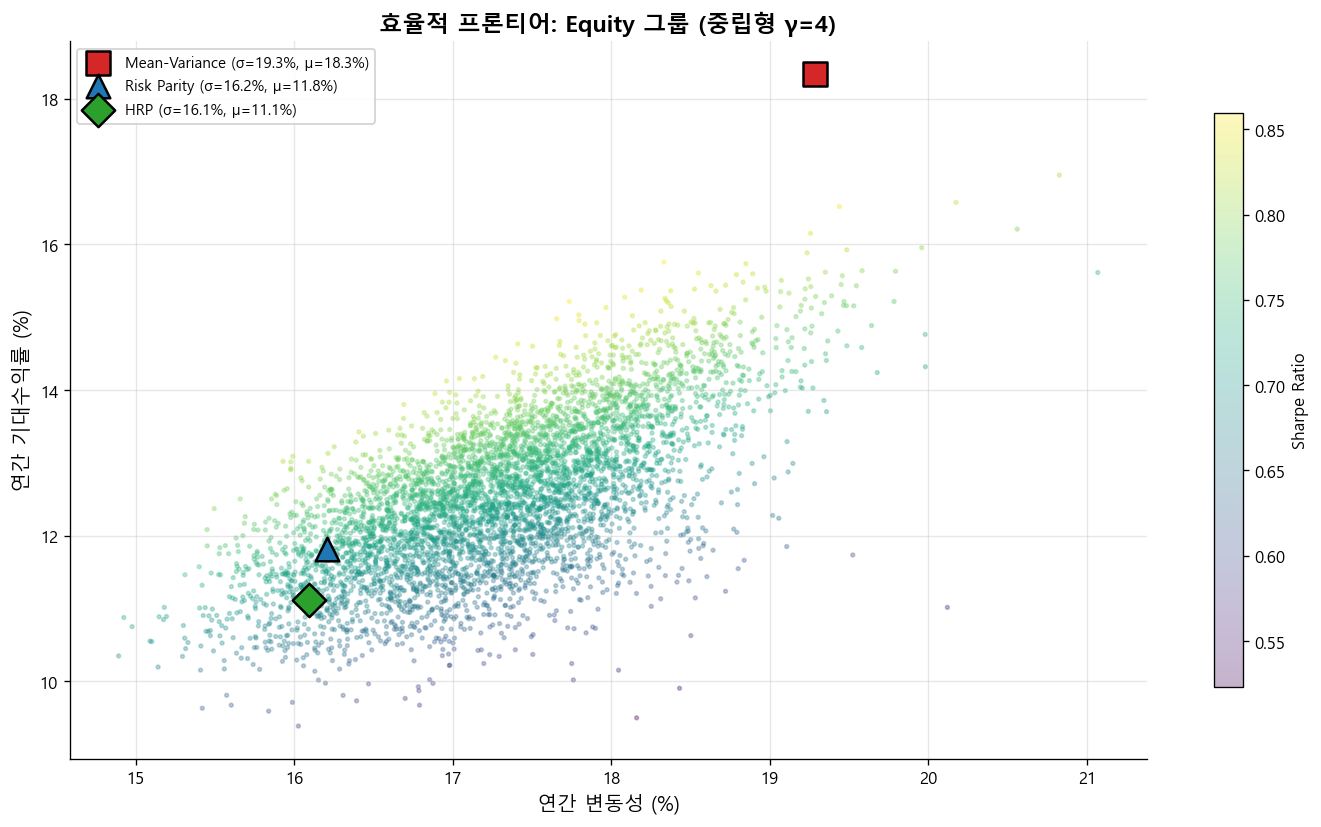

저장: images/step3_03_efficient_frontier.png


In [11]:
# ============================================================
# 시각화: 효율적 프론티어 (중립형 γ=4, Equity 그룹)
# ============================================================
# Equity 그룹 내에서 무작위 포트폴리오를 생성하고,
# MV/RP/HRP 포트폴리오를 프론티어 위에 표시

np.random.seed(42)

n_sims = 5000  # 무작위 포트폴리오 수
n_assets = len(EQUITY_ALL)

# 무작위 포트폴리오 생성
sim_returns = []
sim_vols = []
sim_sharpes = []

for _ in range(n_sims):
    # Dirichlet 분포로 비중 생성 (합이 1인 양수)
    w = np.random.dirichlet(np.ones(n_assets))
    ret = w @ eq_mu
    vol = np.sqrt(w @ eq_cov @ w)
    sim_returns.append(ret)
    sim_vols.append(vol)
    sim_sharpes.append(ret / vol if vol > 0 else 0)

sim_returns = np.array(sim_returns)
sim_vols = np.array(sim_vols)
sim_sharpes = np.array(sim_sharpes)

# MV, RP, HRP 포트폴리오 위치 계산 (중립형 기준)
moderate_profile = PRESETS['중립형']
strat_points = {}
for strat_name, eq_w_key in [('MV', optimize_mv(moderate_profile, eq_mu, eq_cov, EQUITY_ALL)),
                               ('RP', optimize_rp(eq_cov, EQUITY_ALL, moderate_profile['gamma'])),
                               ('HRP', optimize_hrp(eq_ret).values)]:
    w = eq_w_key
    strat_points[strat_name] = {
        'return': w @ eq_mu,
        'vol': np.sqrt(w @ eq_cov @ w)
    }

# 시각화
fig, ax = plt.subplots(figsize=(12, 7))

# 무작위 포트폴리오 산점도 (Sharpe 비율 색상)
scatter = ax.scatter(sim_vols * 100, sim_returns * 100,
                     c=sim_sharpes, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio', shrink=0.8)

# 3가지 전략 포트폴리오 표시
markers = {'MV': 's', 'RP': '^', 'HRP': 'D'}
strat_colors = {'MV': '#d62728', 'RP': '#1f77b4', 'HRP': '#2ca02c'}
strat_labels = {'MV': 'Mean-Variance', 'RP': 'Risk Parity', 'HRP': 'HRP'}

for strat_name, point in strat_points.items():
    ax.scatter(point['vol'] * 100, point['return'] * 100,
              marker=markers[strat_name], color=strat_colors[strat_name],
              s=200, edgecolor='black', linewidth=1.5, zorder=5,
              label=f'{strat_labels[strat_name]} (σ={point["vol"]:.1%}, μ={point["return"]:.1%})')

ax.set_xlabel('연간 변동성 (%)', fontsize=12)
ax.set_ylabel('연간 기대수익률 (%)', fontsize=12)
ax.set_title('효율적 프론티어: Equity 그룹 (중립형 γ=4)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step3_03_efficient_frontier.png'), bbox_inches='tight')
plt.show()
print('저장: images/step3_03_efficient_frontier.png')

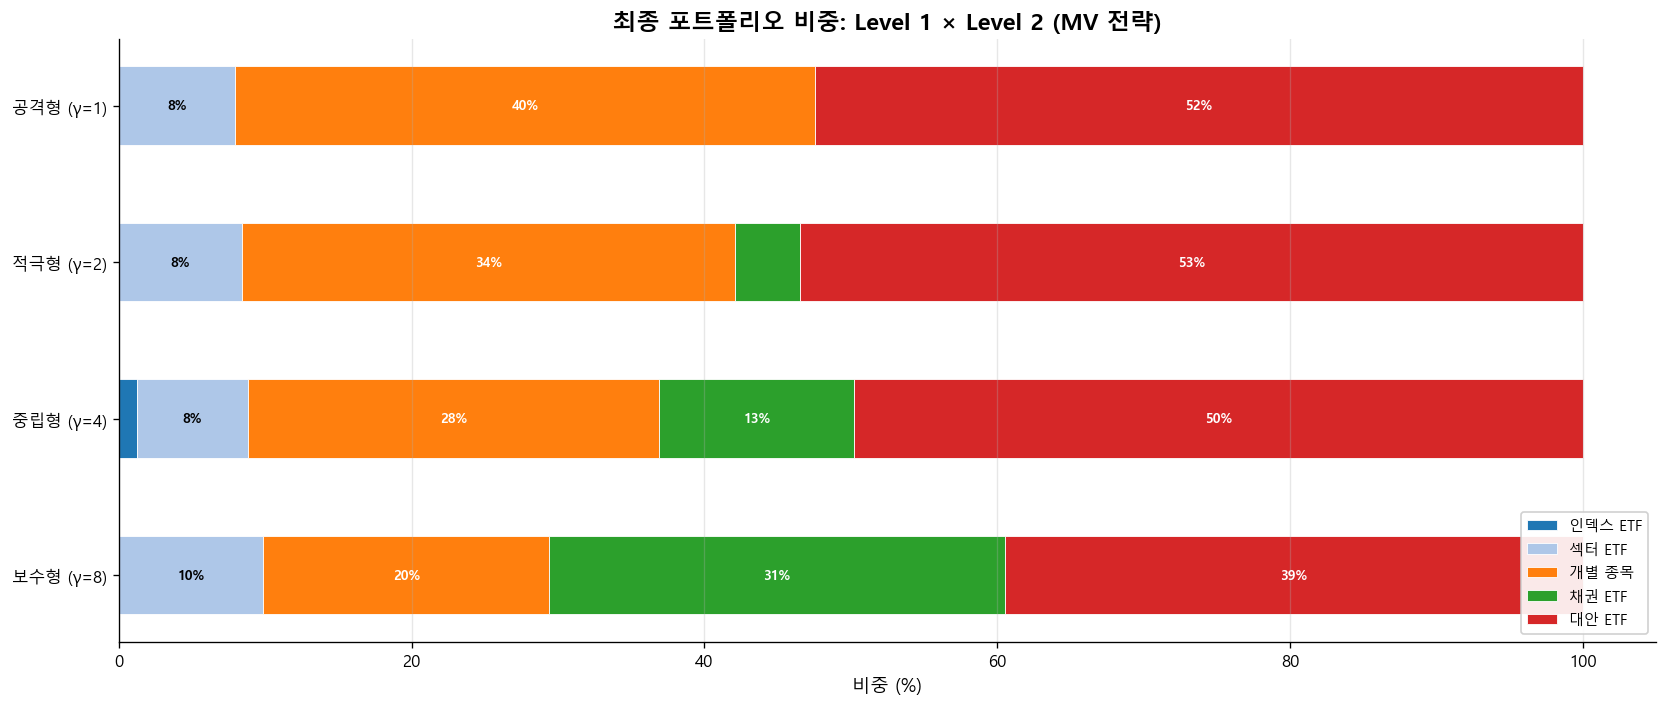

저장: images/step3_04_final_weights.png


In [12]:
# ============================================================
# 시각화: 최종 비중 적층 가로 막대 (4 프로파일 × MV 전략)
# ============================================================
# 30개 자산을 자산군별로 색상 구분하여 적층형 가로 막대로 표시
# 목표: 프로파일별 자산 배분 구성을 한 눈에 비교

fig, ax = plt.subplots(figsize=(14, 6))

profile_names = list(PRESETS.keys())
y_pos = np.arange(len(profile_names))

# 자산군별 색상 매핑
group_colors = {
    '인덱스 ETF': '#1f77b4',
    '섹터 ETF': '#aec7e8',
    '개별 종목': '#ff7f0e',
    '채권 ETF': '#2ca02c',
    '대안 ETF': '#d62728',
}

# 자산군별 그룹 정의
asset_groups_ordered = [
    ('인덱스 ETF', INDEX_ETF),
    ('섹터 ETF', SECTOR_ETF),
    ('개별 종목', STOCKS),
    ('채권 ETF', BOND_ETF),
    ('대안 ETF', ALT_ETF),
]

# 적층 막대 그리기
for prof_idx, prof_name in enumerate(profile_names):
    w = all_weights[prof_name]['MV']
    left = 0
    for group_name, group_tickers in asset_groups_ordered:
        group_w = w[group_tickers].sum() * 100
        bar = ax.barh(prof_idx, group_w, height=0.5, left=left,
                      color=group_colors[group_name],
                      edgecolor='white', linewidth=0.5,
                      label=group_name if prof_idx == 0 else '')
        # 비중이 5% 이상이면 텍스트 표시
        if group_w > 5:
            ax.text(left + group_w / 2, prof_idx, f'{group_w:.0f}%',
                    ha='center', va='center', fontsize=8, fontweight='bold',
                    color='white' if group_w > 10 else 'black')
        left += group_w

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{name} (γ={PRESETS[name]["gamma"]})' for name in profile_names],
                    fontsize=10)
ax.set_xlabel('비중 (%)', fontsize=11)
ax.set_title('최종 포트폴리오 비중: Level 1 × Level 2 (MV 전략)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step3_04_final_weights.png'), bbox_inches='tight')
plt.show()
print('저장: images/step3_04_final_weights.png')

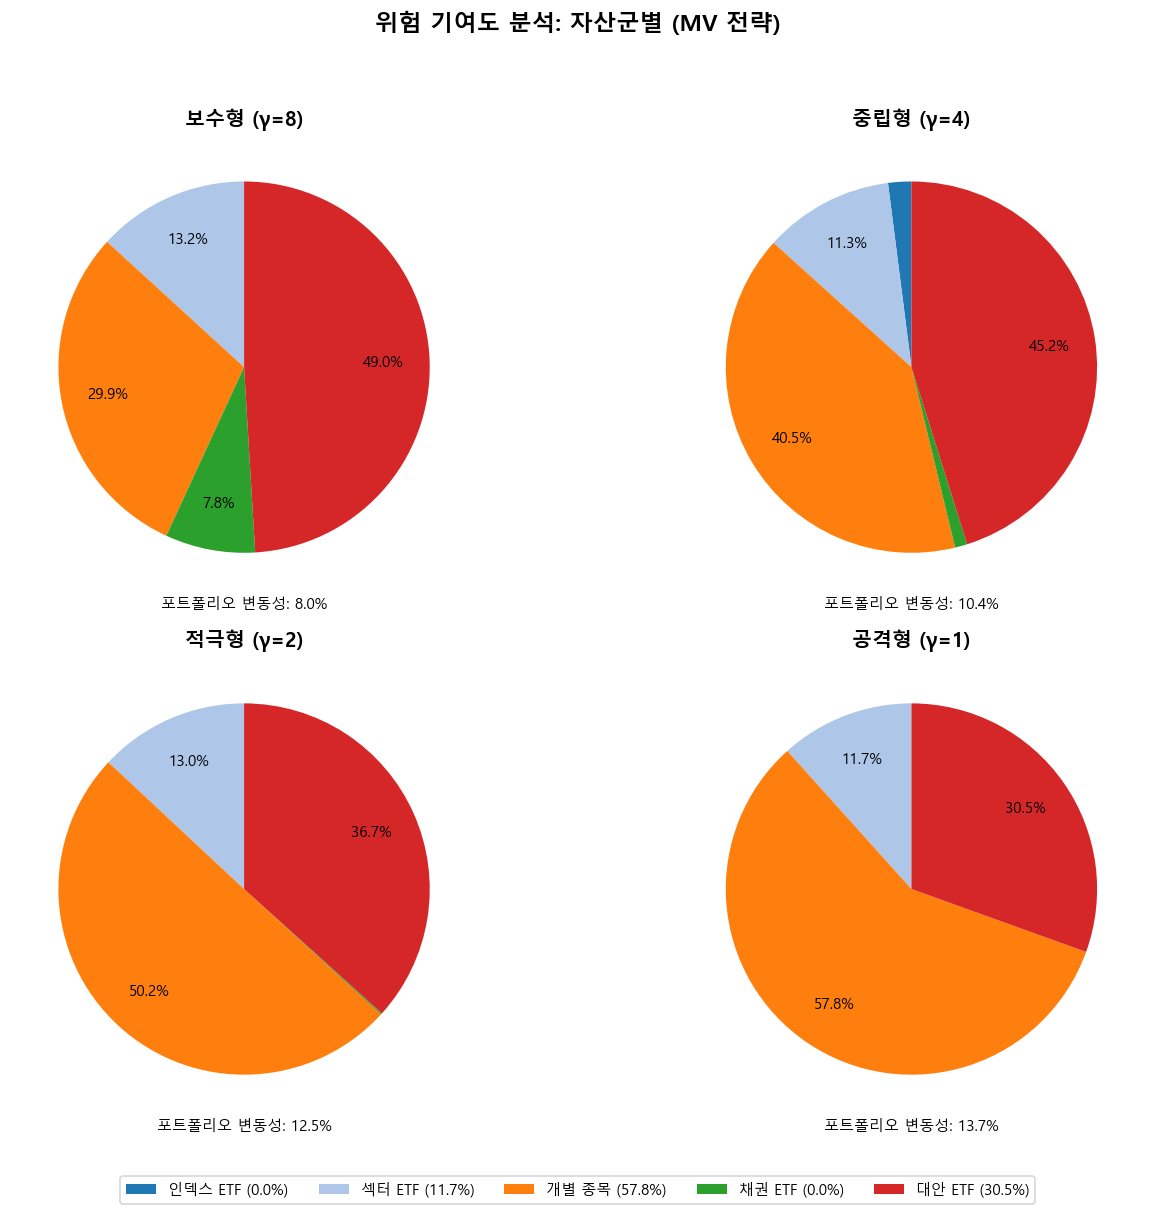

저장: images/step3_05_risk_contribution.png


In [13]:
# ============================================================
# 시각화: 위험 기여도 분석 (4 프로파일, MV 전략)
# ============================================================
# 각 프로파일별로 자산군의 위험 기여도(Risk Contribution)를 파이 차트로 표시
# 위험 기여도: 해당 자산이 포트폴리오 전체 변동성에 기여하는 비율

def risk_contribution(w, cov):
    """
    포트폴리오 위험 기여도 계산.
    
    RC_i = w_i × (Σw)_i / σ_p
    
    Parameters:
        w: N×1 비중 벡터
        cov: N×N 공분산 행렬
    Returns:
        rc: N×1 위험 기여 비율 (합 = 1)
    """
    port_vol = np.sqrt(w @ cov @ w)
    # 한계 위험 기여도
    mrc = cov @ w / port_vol
    # 위험 기여도 = 비중 × 한계 위험 기여도
    rc = w * mrc
    return rc / rc.sum()


# 전체 30개 자산 공분산 (Ledoit-Wolf)
full_cov = LedoitWolf().fit(log_returns).covariance_ * 252

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('위험 기여도 분석: 자산군별 (MV 전략)', fontsize=14, fontweight='bold')

rc_colors = {
    '인덱스 ETF': '#1f77b4',
    '섹터 ETF': '#aec7e8',
    '개별 종목': '#ff7f0e',
    '채권 ETF': '#2ca02c',
    '대안 ETF': '#d62728',
}

for ax, (prof_name, profile) in zip(axes.flat, PRESETS.items()):
    w = all_weights[prof_name]['MV'].values
    rc = risk_contribution(w, full_cov)
    
    # 자산군별 위험 기여도 합산
    group_rc = {}
    tickers = list(df_prices.columns)
    for group_name, group_tickers in asset_groups_ordered:
        group_idx = [tickers.index(t) for t in group_tickers]
        group_rc[group_name] = rc[group_idx].sum()
    
    # 파이 차트
    labels = list(group_rc.keys())
    sizes = [group_rc[l] * 100 for l in labels]
    colors = [rc_colors[l] for l in labels]
    
    # 너무 작은 값은 라벨 생략
    def autopct_func(pct):
        return f'{pct:.1f}%' if pct > 3 else ''
    
    wedges, texts, autotexts = ax.pie(
        sizes, labels=None, colors=colors,
        autopct=autopct_func, startangle=90,
        pctdistance=0.75, textprops={'fontsize': 9}
    )
    
    # 범례 (첫 번째 차트에만)
    ax.set_title(f'{prof_name} (γ={profile["gamma"]})', fontsize=12, fontweight='bold')
    
    # 포트폴리오 변동성 표시
    port_vol = np.sqrt(w @ full_cov @ w)
    ax.text(0, -1.3, f'포트폴리오 변동성: {port_vol:.1%}', ha='center', fontsize=9)

# 공통 범례
fig.legend(labels=[f'{name} ({sizes[i]:.1f}%)' for i, name in enumerate(labels)],
           loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(os.path.join(IMG_DIR, 'step3_05_risk_contribution.png'), bbox_inches='tight')
plt.show()
print('저장: images/step3_05_risk_contribution.png')

In [14]:
# ============================================================
# 결과 저장
# ============================================================

# 1. 최적화된 비중 저장 (4 프로파일 × 3 전략 = 12개 포트폴리오)
weight_records = []
for prof_name in PRESETS.keys():
    for strat_name in ['MV', 'RP', 'HRP']:
        w = all_weights[prof_name][strat_name]
        for ticker, weight in w.items():
            weight_records.append({
                'profile': prof_name,
                'gamma': PRESETS[prof_name]['gamma'],
                'strategy': strat_name,
                'ticker': ticker,
                'weight': weight,
            })

df_weights = pd.DataFrame(weight_records)
weights_path = os.path.join(DATA_DIR, 'optimal_weights.csv')
df_weights.to_csv(weights_path, index=False)
print(f'비중 저장: {weights_path}')
print(f'  {df_weights.shape[0]}개 레코드 (4 프로파일 × 3 전략 × 30 종목)')

# 2. 프로파일 정의 저장
profile_records = []
for name, p in PRESETS.items():
    profile_records.append({
        'profile': name,
        'gamma': p['gamma'],
        'target_vol': p['target_vol'],
        'max_equity': p['max_equity'],
        'min_bond': p['min_bond'],
        'max_mdd': p['max_mdd'],
        'l1_equity': l1_weights[name][0],
        'l1_bond': l1_weights[name][1],
        'l1_alt': l1_weights[name][2],
    })

df_profiles = pd.DataFrame(profile_records)
profiles_path = os.path.join(DATA_DIR, 'profiles.csv')
df_profiles.to_csv(profiles_path, index=False)
print(f'\n프로파일 저장: {profiles_path}')
print(df_profiles.to_string(index=False))

비중 저장: C:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ12_Asset_Simulater\PJ12_v3_Final\data\optimal_weights.csv
  360개 레코드 (4 프로파일 × 3 전략 × 30 종목)

프로파일 저장: C:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ12_Asset_Simulater\PJ12_v3_Final\data\profiles.csv
profile  gamma  target_vol  max_equity  min_bond   max_mdd  l1_equity  l1_bond   l1_alt
    보수형      8    0.103333    0.433333  0.311111 -0.155556   0.293985 0.311111 0.394904
    중립형      4    0.170000    0.700000  0.133333 -0.266667   0.369131 0.133333 0.497536
    적극형      2    0.203333    0.833333  0.044444 -0.322222   0.421085 0.044444 0.534470
    공격형      1    0.220000    0.900000  0.000000 -0.350000   0.475827 0.000000 0.524173


In [15]:
# ============================================================
# Step 3 완료 요약
# ============================================================

print('=' * 70)
print('Step 3. 포트폴리오 최적화 완료')
print('=' * 70)

print(f'\n[입력 데이터]')
print(f'  - portfolio_prices.csv: 30개 자산, {df_prices.shape[0]}일')
print(f'  - 기간: {df_prices.index[0].date()} ~ {df_prices.index[-1].date()}')

print(f'\n[최적화 구조]')
print(f'  - Level 1: 블록 대각 (SPY/AGG/GLD) → 자산군 비중 결정')
print(f'  - Level 2: Equity(PCA Factor), Bond(LW), Alt(역변동성)')
print(f'  - 전략: Mean-Variance, Risk Parity, HRP')
print(f'  - 프로파일: 보수형(γ=8), 중립형(γ=4), 적극형(γ=2), 공격형(γ=1)')

print(f'\n[최적화 결과: 12개 포트폴리오 (4 × 3)]')
for prof_name in PRESETS.keys():
    w_mv = all_weights[prof_name]['MV'].values
    port_vol = np.sqrt(w_mv @ full_cov @ w_mv)
    port_ret = w_mv @ (log_returns.mean().values * 252)
    print(f'  {prof_name:6s} (MV): 기대수익률 {port_ret:+.2%}, 변동성 {port_vol:.2%}')

print(f'\n[저장 파일]')
print(f'  - data/optimal_weights.csv: {df_weights.shape[0]}개 레코드')
print(f'  - data/profiles.csv: {len(PRESETS)}개 프로파일')
print(f'  - images/step3_01_profiles.png')
print(f'  - images/step3_02_level1_allocation.png')
print(f'  - images/step3_03_efficient_frontier.png')
print(f'  - images/step3_04_final_weights.png')
print(f'  - images/step3_05_risk_contribution.png')

print(f'\n→ Step 4에서 백테스트 및 성과 평가를 수행합니다.')

Step 3. 포트폴리오 최적화 완료

[입력 데이터]
  - portfolio_prices.csv: 30개 자산, 2609일
  - 기간: 2016-01-01 ~ 2025-12-31

[최적화 구조]
  - Level 1: 블록 대각 (SPY/AGG/GLD) → 자산군 비중 결정
  - Level 2: Equity(PCA Factor), Bond(LW), Alt(역변동성)
  - 전략: Mean-Variance, Risk Parity, HRP
  - 프로파일: 보수형(γ=8), 중립형(γ=4), 적극형(γ=2), 공격형(γ=1)

[최적화 결과: 12개 포트폴리오 (4 × 3)]
  보수형    (MV): 기대수익률 +8.91%, 변동성 8.02%
  중립형    (MV): 기대수익률 +12.05%, 변동성 10.42%
  적극형    (MV): 기대수익률 +14.32%, 변동성 12.54%
  공격형    (MV): 기대수익률 +15.46%, 변동성 13.68%

[저장 파일]
  - data/optimal_weights.csv: 360개 레코드
  - data/profiles.csv: 4개 프로파일
  - images/step3_01_profiles.png
  - images/step3_02_level1_allocation.png
  - images/step3_03_efficient_frontier.png
  - images/step3_04_final_weights.png
  - images/step3_05_risk_contribution.png

→ Step 4에서 백테스트 및 성과 평가를 수행합니다.
